# 05 - End-to-end project: retention risk after onboarding

Business story:

> A SaaS company wants to know which customers are likely to churn after onboarding, and when the customer success team should intervene.

We will build this as a **landmark survival problem**.

- Landmark: day 30 after signup.
- Features: only behavior observed in the first 30 days.
- Event: churn after day 30.
- Censoring: customers still active when the study ends.

This design protects the model from future information.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

def find_intro_dir():
    cwd = Path.cwd()
    if cwd.name == "survival-analysis-intro":
        return cwd
    if cwd.name == "notebooks" and cwd.parent.name == "survival-analysis-intro":
        return cwd.parent
    candidate = cwd / "survival-analysis-intro"
    if candidate.exists():
        return candidate
    return cwd

INTRO_DIR = find_intro_dir()
DATA_DIR = INTRO_DIR / "data"
OUTPUT_DIR = INTRO_DIR / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 140)

In [2]:
from lifelines import CoxPHFitter, KaplanMeierFitter
from sklearn.preprocessing import StandardScaler

raw = pd.read_csv(DATA_DIR / "subscription_retention_project.csv", parse_dates=["signup_date"])
raw.head()

,customer_id,signup_date,plan,acquisition_channel,region,company_size,annual_contract,first_30_logins,key_feature_events_30,support_tickets_30,payment_failures_30,onboarding_score_30,duration_days_since_signup,churn_observed,study_end_date
0,R00001,2024-09-08,Starter,Paid Search,North America,11-50,0,8,6,2,0,65.9,295,0,2025-06-30
1,R00002,2024-11-06,Starter,Paid Search,APAC,1-10,0,10,1,1,0,62.9,233,1,2025-06-30
2,R00003,2024-03-27,Starter,Paid Search,APAC,51-200,0,3,3,0,0,51.6,144,1,2025-06-30
3,R00004,2024-02-08,Growth,Partner,LATAM,1-10,0,8,4,0,0,58.0,508,0,2025-06-30
4,R00005,2024-12-01,Starter,Organic,North America,11-50,0,9,3,1,1,28.2,211,0,2025-06-30


## Step 1: define the modeling population

We only score customers who reached day 30 without observed churn. Customers who churned before day 30 are a different problem: early activation rescue, not post-onboarding retention.

In [3]:
LANDMARK_DAY = 30

data = raw.copy()
data["active_at_landmark"] = (data["duration_days_since_signup"] > LANDMARK_DAY) | data["churn_observed"].eq(0)
landmark = data[data["active_at_landmark"]].copy()

landmark["time_from_day30"] = np.where(
    landmark["churn_observed"].eq(1),
    landmark["duration_days_since_signup"] - LANDMARK_DAY,
    landmark["duration_days_since_signup"] - LANDMARK_DAY,
).clip(1)

print("raw customers:", len(raw))
print("eligible at day 30:", len(landmark))
print("excluded early churners:", len(raw) - len(landmark))
print("post-landmark churn rate:", round(landmark["churn_observed"].mean(), 3))

raw customers: 2600
eligible at day 30: 2464
excluded early churners: 136
post-landmark churn rate: 0.486


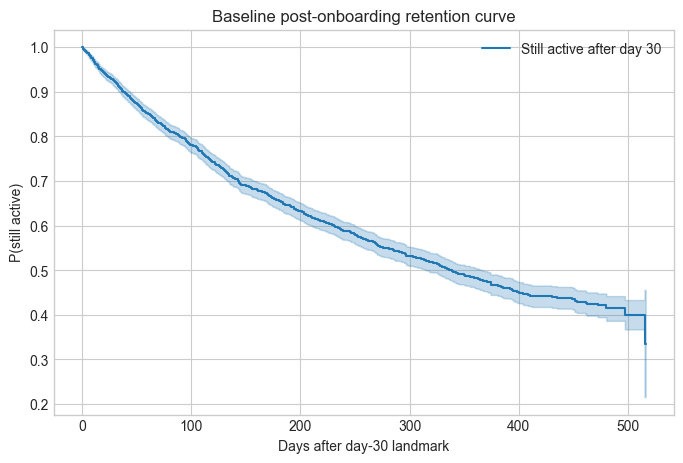

,days_after_day30,baseline_P_active
0,30,0.921
1,60,0.851
2,90,0.799
3,180,0.655
4,270,0.556


In [4]:
km = KaplanMeierFitter()
km.fit(landmark["time_from_day30"], landmark["churn_observed"], label="Still active after day 30")

ax = km.plot_survival_function(figsize=(8, 5))
ax.set_title("Baseline post-onboarding retention curve")
ax.set_xlabel("Days after day-30 landmark")
ax.set_ylabel("P(still active)")
plt.show()

pd.DataFrame({
    "days_after_day30": [30, 60, 90, 180, 270],
    "baseline_P_active": km.survival_function_at_times([30, 60, 90, 180, 270]).values.round(3),
})

## Step 2: split like a future deployment

Random splits are sometimes fine for teaching, but production retention models usually face future customers.

Here we train on earlier signups and test on later signups. This is harder and more honest.

In [5]:
cutoff = pd.Timestamp("2024-10-01")
train_raw = landmark[landmark["signup_date"] < cutoff].copy()
test_raw = landmark[landmark["signup_date"] >= cutoff].copy()

feature_cols = [
    "plan",
    "acquisition_channel",
    "region",
    "company_size",
    "annual_contract",
    "first_30_logins",
    "key_feature_events_30",
    "support_tickets_30",
    "payment_failures_30",
    "onboarding_score_30",
]

train_X = pd.get_dummies(train_raw[feature_cols], drop_first=True)
test_X = pd.get_dummies(test_raw[feature_cols], drop_first=True)
train_X, test_X = train_X.align(test_X, join="left", axis=1, fill_value=0)

numeric_cols = [
    "first_30_logins",
    "key_feature_events_30",
    "support_tickets_30",
    "payment_failures_30",
    "onboarding_score_30",
]
scaler = StandardScaler()
train_X[numeric_cols] = scaler.fit_transform(train_X[numeric_cols])
test_X[numeric_cols] = scaler.transform(test_X[numeric_cols])

train_model = train_X.copy()
train_model["time_from_day30"] = train_raw["time_from_day30"].values
train_model["churn_observed"] = train_raw["churn_observed"].values

test_model = test_X.copy()
test_model["time_from_day30"] = test_raw["time_from_day30"].values
test_model["churn_observed"] = test_raw["churn_observed"].values

print("train:", train_model.shape, "event rate:", round(train_model["churn_observed"].mean(), 3))
print("test:", test_model.shape, "event rate:", round(test_model["churn_observed"].mean(), 3))

train: (1857, 19) event rate: 0.516
test: (607, 19) event rate: 0.392


## Step 3: fit Cox and interpret drivers

The coefficient table is useful, but the stakeholder-friendly version is the hazard ratio table.

In [6]:
cph = CoxPHFitter(penalizer=0.08)
cph.fit(train_model, duration_col="time_from_day30", event_col="churn_observed")

print("Train concordance:", round(cph.concordance_index_, 3))
print("Future-cohort test concordance:", round(cph.score(test_model, scoring_method="concordance_index"), 3))

hr = (
    cph.summary[["exp(coef)", "p"]]
    .rename(columns={"exp(coef)": "hazard_ratio"})
    .sort_values("hazard_ratio", ascending=False)
)
hr.head(12).round(3)

Train concordance: 0.732
Future-cohort test concordance: 0.72


,hazard_ratio,p
covariate,,
plan_Starter,1.590,0.000
acquisition_channel_Paid Search,1.211,0.006
support_tickets_30,1.207,0.000
region_LATAM,1.181,0.110
payment_failures_30,1.149,0.000
company_size_11-50,1.109,0.123
company_size_51-200,1.100,0.269
region_Europe,1.100,0.246
region_North America,1.021,0.801


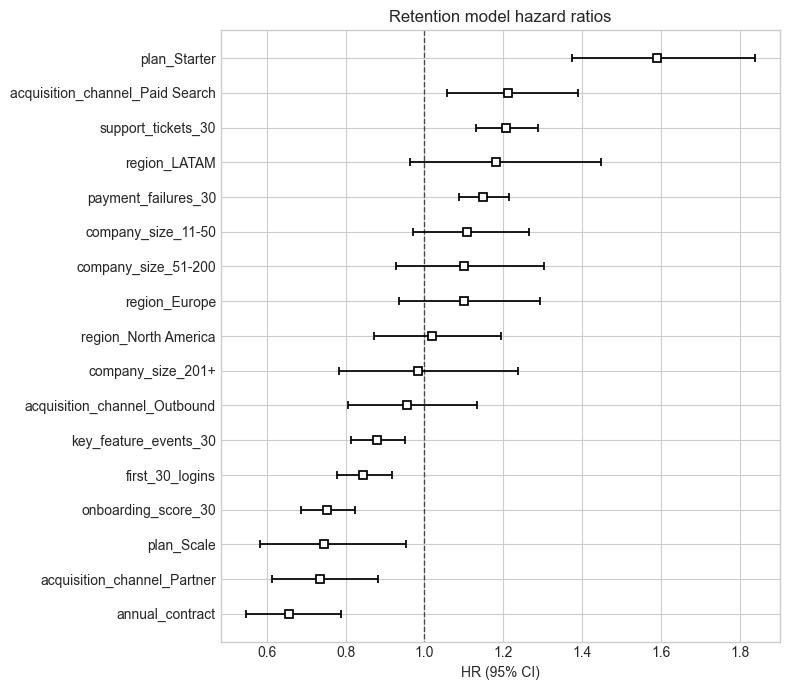

In [7]:
fig, ax = plt.subplots(figsize=(8, 7))
cph.plot(hazard_ratios=True, ax=ax)
ax.set_title("Retention model hazard ratios")
plt.tight_layout()
plt.show()

## Step 4: produce a scorecard

A model becomes useful when it turns into an action table.

Here we estimate survival from the day-30 landmark:

- `S_60d_after_day30`: probability the customer is still active 60 days after day 30.
- `S_180d_after_day30`: probability the customer is still active 180 days after day 30.
- `risk_tier`: a simple operational grouping.

In [8]:
scoring_X = test_X.copy()
survival_60 = cph.predict_survival_function(scoring_X, times=[60]).T[60]
survival_180 = cph.predict_survival_function(scoring_X, times=[180]).T[180]
risk_score = cph.predict_partial_hazard(scoring_X).values.ravel()

scorecard = test_raw[[
    "customer_id",
    "signup_date",
    "plan",
    "acquisition_channel",
    "region",
    "company_size",
    "annual_contract",
    "first_30_logins",
    "key_feature_events_30",
    "support_tickets_30",
    "payment_failures_30",
    "onboarding_score_30",
    "time_from_day30",
    "churn_observed",
]].copy()
scorecard["risk_score"] = risk_score
scorecard["S_60d_after_day30"] = survival_60.values
scorecard["S_180d_after_day30"] = survival_180.values
scorecard["risk_percentile"] = scorecard["risk_score"].rank(pct=True)
scorecard["risk_tier"] = pd.cut(
    scorecard["risk_percentile"],
    bins=[0, 0.70, 0.90, 1.0],
    labels=["Monitor", "Customer success watchlist", "Immediate intervention"],
    include_lowest=True,
)

scorecard.sort_values("risk_score", ascending=False).head(10)

,customer_id,signup_date,plan,acquisition_channel,region,company_size,annual_contract,first_30_logins,key_feature_events_30,support_tickets_30,payment_failures_30,onboarding_score_30,time_from_day30,churn_observed,risk_score,S_60d_after_day30,S_180d_after_day30,risk_percentile,risk_tier
2223,R02224,2024-11-01,Starter,Paid Search,North America,1-10,0,0,2,6,0,13.1,74,1,9.743655,0.331379,0.037073,1.000000,Immediate intervention
2451,R02452,2024-10-21,Starter,Organic,North America,1-10,0,5,1,3,1,8.3,32,1,6.743836,0.465591,0.102237,0.998353,Immediate intervention
103,R00104,2024-10-10,Starter,Organic,Europe,11-50,0,3,3,3,1,25.5,94,1,5.941381,0.509928,0.134108,0.996705,Immediate intervention
2220,R02221,2024-12-14,Starter,Paid Search,North America,11-50,0,2,1,2,0,13.1,80,1,5.530876,0.534218,0.154078,0.995058,Immediate intervention
2367,R02368,2024-11-19,Starter,Paid Search,North America,51-200,0,5,1,4,0,29.3,37,1,5.024961,0.565749,0.182827,0.993410,Immediate intervention
1988,R01989,2024-10-03,Starter,Paid Search,Europe,1-10,0,2,0,2,0,24.3,206,1,4.773663,0.582097,0.199042,0.991763,Immediate intervention
1042,R01043,2024-12-01,Starter,Paid Search,APAC,51-200,1,6,1,3,1,19.5,175,1,4.606701,0.593219,0.210603,0.990115,Immediate intervention
786,R00787,2024-10-21,Starter,Partner,LATAM,11-50,0,2,1,3,0,12.4,222,0,4.606528,0.593230,0.210616,0.988468,Immediate intervention
1980,R01981,2024-12-22,Starter,Paid Search,Europe,1-10,0,5,0,3,0,27.7,33,1,4.585859,0.594622,0.212093,0.986820,Immediate intervention
712,R00713,2024-10-19,Starter,Paid Search,Europe,1-10,0,4,0,2,0,21.3,7,1,4.551438,0.596946,0.214576,0.985173,Immediate intervention


In [9]:
scorecard.groupby("risk_tier", observed=True).agg(
    customers=("customer_id", "count"),
    observed_churn_rate=("churn_observed", "mean"),
    avg_S_60d=("S_60d_after_day30", "mean"),
    avg_S_180d=("S_180d_after_day30", "mean"),
    avg_first_30_logins=("first_30_logins", "mean"),
    avg_onboarding_score=("onboarding_score_30", "mean"),
).round(3)

,customers,observed_churn_rate,avg_S_60d,avg_S_180d,avg_first_30_logins,avg_onboarding_score
risk_tier,,,,,,
Monitor,424,0.274,0.918,0.780,8.811,62.446
Customer success watchlist,122,0.598,0.778,0.475,5.295,40.953
Immediate intervention,61,0.803,0.653,0.288,3.492,31.826


In [10]:
out_path = OUTPUT_DIR / "retention_risk_scorecard.csv"
scorecard.to_csv(out_path, index=False)
print(f"Scorecard written to {out_path.relative_to(OUTPUT_DIR.parent.parent)}")

Scorecard written to survival-analysis-intro/outputs/retention_risk_scorecard.csv


## Step 5: write the recommendation

A concise recommendation could be:

> Use the day-30 retention survival model for customers who complete onboarding without early churn. The model ranks future-cohort churn risk reasonably well and converts that ranking into 60-day and 180-day survival probabilities. Prioritize the highest-risk decile for immediate customer-success intervention, especially accounts with low first-30-day usage, weak onboarding scores, payment failures, or unresolved support friction.

What we would do before production:

- Confirm the event definition with finance and customer success.
- Backtest on multiple signup cohorts, not just one cutoff.
- Monitor calibration by risk tier.
- Run an experiment to measure whether intervention changes retention.
- Refit on a schedule because onboarding behavior and customer mix drift.

Survival analysis is not just a model. It is a disciplined way to make time, uncertainty, and action fit together.